In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
close_prices = pd.read_csv('../data/processed/close_prices.csv', 
                            index_col='Date', parse_dates=True)

# Focus on TSLA for forecasting
tsla = close_prices['TSLA'].dropna()

print(f"TSLA data loaded: {len(tsla)} trading days")
print(f"Date range: {tsla.index[0].date()} to {tsla.index[-1].date()}")
print(f"Price range: ${tsla.min():.2f} to ${tsla.max():.2f}")

TSLA data loaded: 2888 trading days
Date range: 2015-01-02 to 2026-06-29
Price range: $9.58 to $489.88


Training set: 2015-01-02 to 2024-12-31 (2516 days)
Testing set:  2025-01-02 to 2026-06-29 (372 days)


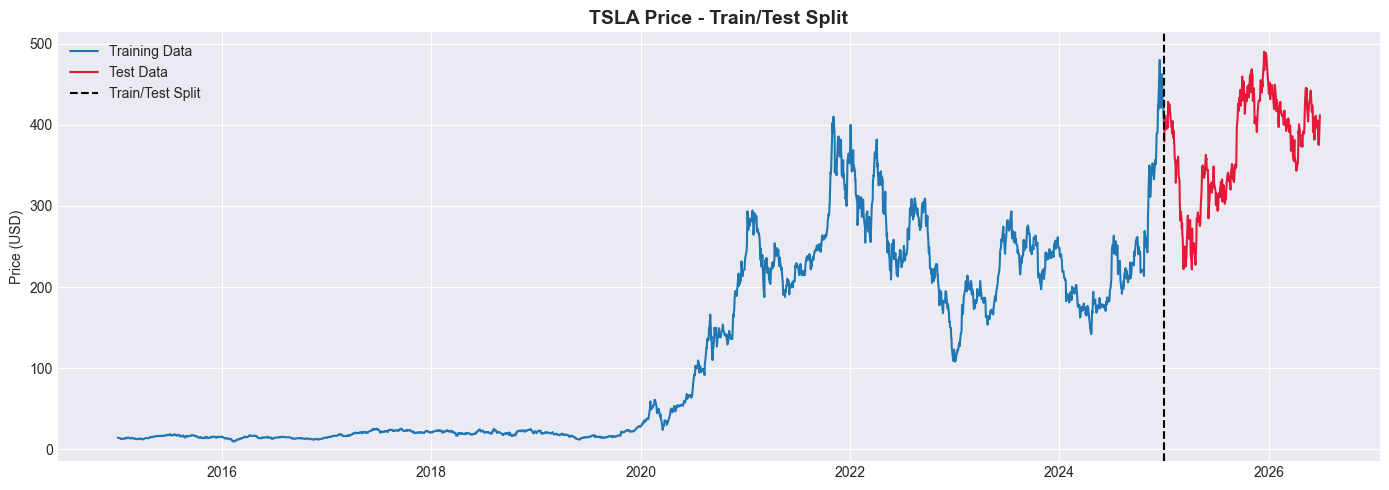

Split done!


In [2]:

# Split chronologically - train on 2015-2024, test on 2025-2026
train_end = '2024-12-31'
test_start = '2025-01-01'

train = tsla[:train_end]
test = tsla[test_start:]

print(f"Training set: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} days)")
print(f"Testing set:  {test.index[0].date()} to {test.index[-1].date()} ({len(test)} days)")

# Plot the split
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, color='#1f77b4', linewidth=1.5, label='Training Data')
plt.plot(test.index, test, color='#E31937', linewidth=1.5, label='Test Data')
plt.axvline(x=pd.Timestamp(test_start), color='black', linestyle='--', linewidth=1.5, label='Train/Test Split')
plt.title('TSLA Price - Train/Test Split', fontsize=14, fontweight='bold')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()
print("Split done!")

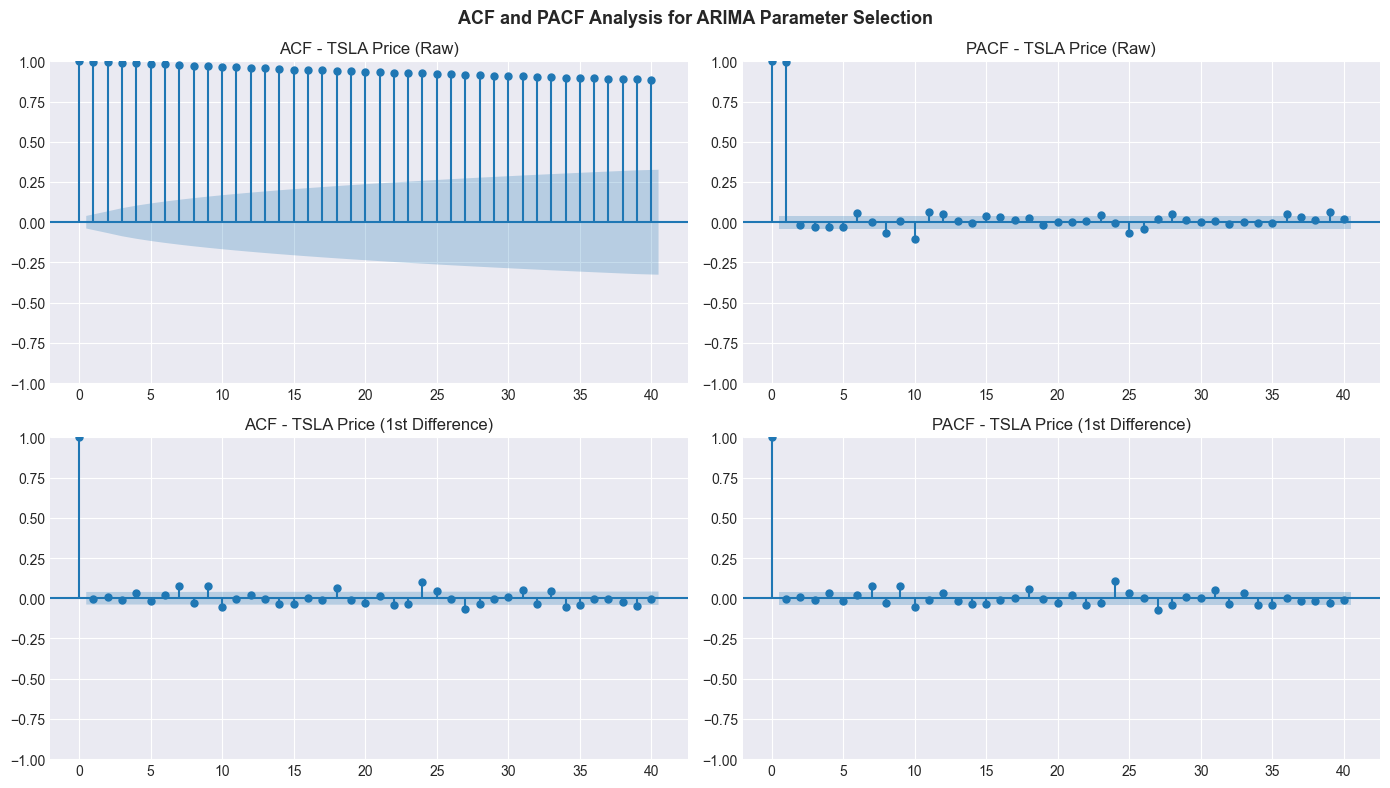

ACF/PACF plots done!


In [3]:

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF and PACF on raw prices
plot_acf(train, lags=40, ax=axes[0, 0], title='ACF - TSLA Price (Raw)')
plot_pacf(train, lags=40, ax=axes[0, 1], title='PACF - TSLA Price (Raw)')

# Differenced series (to make stationary)
train_diff = train.diff().dropna()
plot_acf(train_diff, lags=40, ax=axes[1, 0], title='ACF - TSLA Price (1st Difference)')
plot_pacf(train_diff, lags=40, ax=axes[1, 1], title='PACF - TSLA Price (1st Difference)')

plt.suptitle('ACF and PACF Analysis for ARIMA Parameter Selection', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("ACF/PACF plots done!")

In [4]:

print("Running auto_arima to find optimal parameters...")
print("This may take 2-3 minutes...\n")

auto_model = pm.auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=1,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    information_criterion='aic',
    trace=True
)

print(f"\nBest ARIMA order: {auto_model.order}")
print(f"AIC: {auto_model.aic():.2f}")
print(auto_model.summary())

Running auto_arima to find optimal parameters...
This may take 2-3 minutes...

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.37 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.57 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.83 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.071 seconds

Best ARIMA order: (0, 1, 0)
AIC: 16368.11
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        13:03:15   BIC                          16373.939
Sample:                     

Fitting ARIMA(0, 1, 0) model...
Forecast generated for 372 days


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Pred

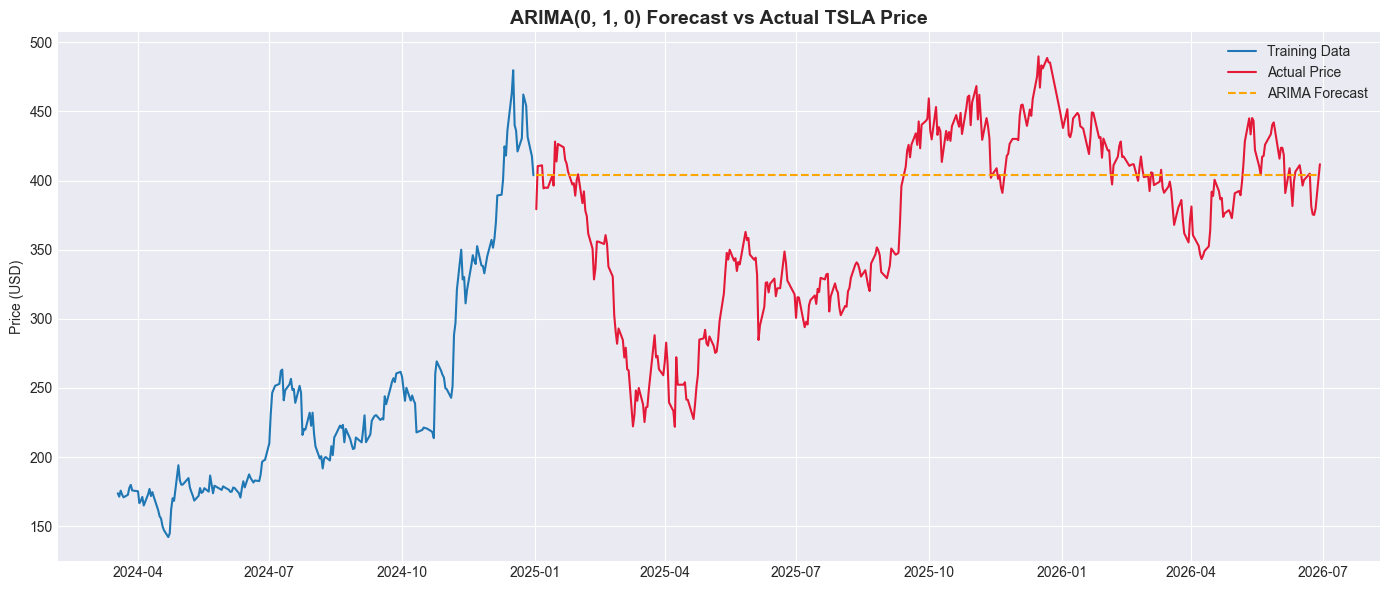

Forecast plot done!


In [5]:

order = auto_model.order
print(f"Fitting ARIMA{order} model...")

# Fit on training data
arima_model = ARIMA(train, order=order)
arima_result = arima_model.fit()

# Forecast on test period
forecast_steps = len(test)
forecast = arima_result.forecast(steps=forecast_steps)
forecast.index = test.index

print(f"Forecast generated for {forecast_steps} days")

# Plot
plt.figure(figsize=(14, 6))
plt.plot(train[-200:].index, train[-200:], color='#1f77b4', linewidth=1.5, label='Training Data')
plt.plot(test.index, test, color='#E31937', linewidth=1.5, label='Actual Price')
plt.plot(forecast.index, forecast, color='orange', linewidth=1.5, linestyle='--', label='ARIMA Forecast')
plt.title(f'ARIMA{order} Forecast vs Actual TSLA Price', fontsize=14, fontweight='bold')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()
print("Forecast plot done!")

In [6]:

def calculate_metrics(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    print(f"=== {model_name} Performance ===")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print()
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

arima_metrics = calculate_metrics(test.values, forecast.values, f'ARIMA{order}')

=== ARIMA(0, 1, 0) Performance ===
MAE:  54.4412
RMSE: 70.5393
MAPE: 17.2407%



In [7]:

from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow version: {tf.__version__}")

# Scale data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
tsla_scaled = scaler.fit_transform(tsla.values.reshape(-1, 1))

# Split scaled data
train_scaled = tsla_scaled[:len(train)]
test_scaled = tsla_scaled[len(train):]

# Create sequences - use last 60 days to predict next day
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequences(train_scaled, window_size)

# For test, include last 60 days of training
combined = np.concatenate([train_scaled[-window_size:], test_scaled])
X_test, y_test = create_sequences(combined, window_size)

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print("Data prepared for LSTM!")

TensorFlow version: 2.21.0
X_train shape: (2456, 60, 1)
X_test shape:  (372, 60, 1)
y_train shape: (2456,)
Data prepared for LSTM!


In [8]:

print("Building LSTM model...")

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nTraining LSTM model...")
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete!")

Building LSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 0.0061 - val_loss: 0.0023
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 9.3694e-04 - val_loss: 0.0036
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 8.8376e-04 - val_loss: 0.0017
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 9.3279e-04 - val_loss: 0.0014
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 7.7590e-04 - val_loss: 0.0013
Epoch 12/50
70/70 ━━━

Generating LSTM predictions...
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step


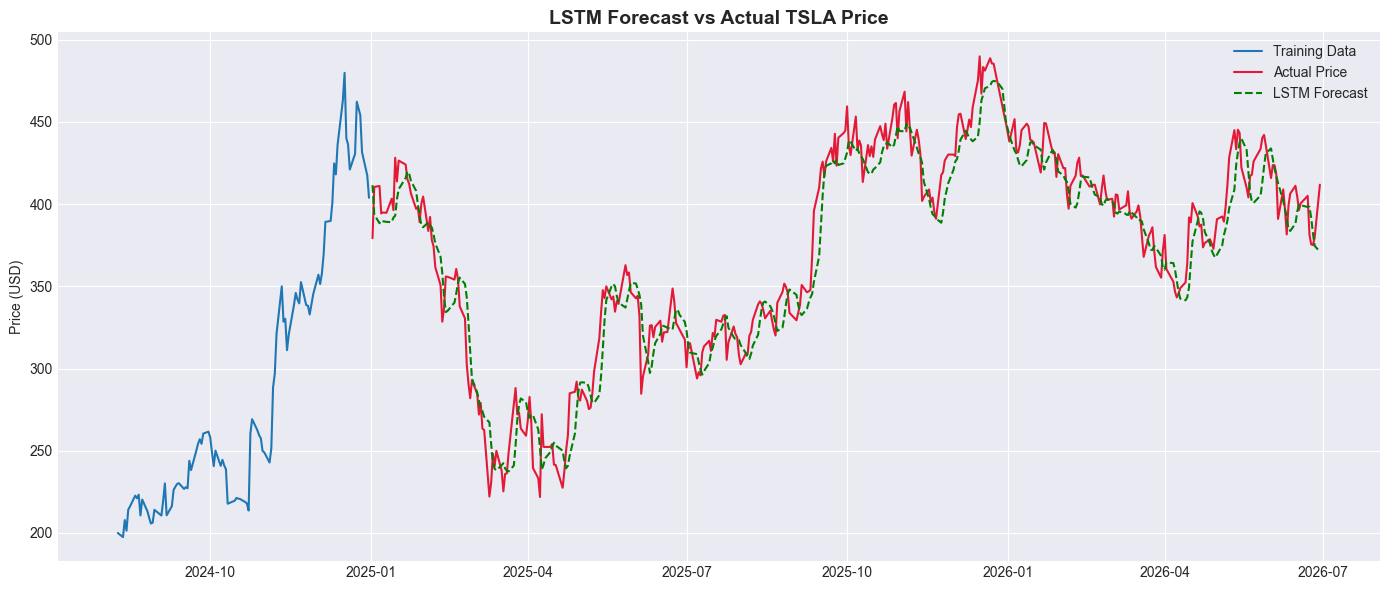

LSTM prediction plot done!


In [9]:

print("Generating LSTM predictions...")

# Predict
lstm_pred_scaled = model.predict(X_test)

# Inverse transform to get actual prices
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
actual_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot
plt.figure(figsize=(14, 6))
plt.plot(train[-100:].index, train[-100:], 
         color='#1f77b4', linewidth=1.5, label='Training Data')
plt.plot(test.index, actual_test, 
         color='#E31937', linewidth=1.5, label='Actual Price')
plt.plot(test.index, lstm_pred, 
         color='green', linewidth=1.5, linestyle='--', label='LSTM Forecast')
plt.title('LSTM Forecast vs Actual TSLA Price', fontsize=14, fontweight='bold')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()
print("LSTM prediction plot done!")

=== LSTM Performance ===
MAE:  12.5247
RMSE: 15.9393
MAPE: 3.5021%


=== MODEL COMPARISON TABLE ===
                    MAE     RMSE     MAPE
Model                                    
ARIMA(0, 1, 0)  54.4412  70.5393  17.2407
LSTM            12.5247  15.9393   3.5021


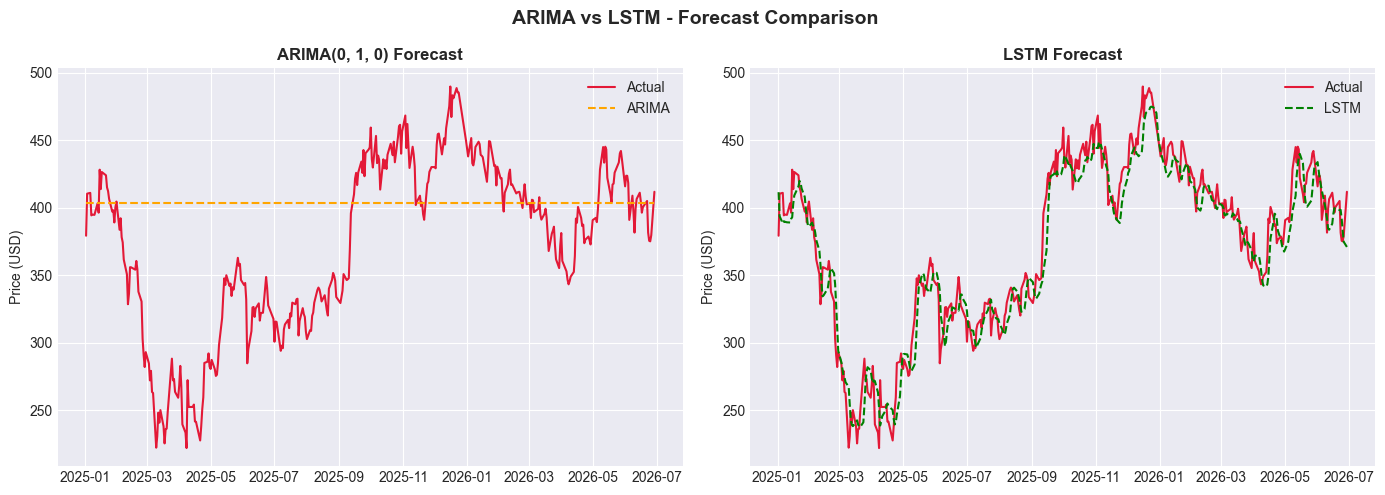


Best model based on RMSE: LSTM


In [10]:

lstm_metrics = calculate_metrics(
    actual_test.flatten(),
    lstm_pred.flatten(),
    'LSTM'
)

# Comparison table
results = pd.DataFrame([arima_metrics, lstm_metrics])
results = results.set_index('Model')
results = results.round(4)

print("\n=== MODEL COMPARISON TABLE ===")
print(results.to_string())

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ARIMA plot
axes[0].plot(test.index, test.values, color='#E31937', linewidth=1.5, label='Actual')
axes[0].plot(test.index, forecast.values, color='orange', linewidth=1.5, 
             linestyle='--', label='ARIMA')
axes[0].set_title(f'ARIMA{order} Forecast', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# LSTM plot
axes[1].plot(test.index, actual_test, color='#E31937', linewidth=1.5, label='Actual')
axes[1].plot(test.index, lstm_pred, color='green', linewidth=1.5, 
             linestyle='--', label='LSTM')
axes[1].set_title('LSTM Forecast', fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.suptitle('ARIMA vs LSTM - Forecast Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nBest model based on RMSE:", results['RMSE'].idxmin())